- Curso: PPG em Genética e Biologia Molecular (PPGBM-UFPA)
- Disciplina: IA na Descoberta Genética
- Tema: Deep Learning para Genômica
- Docente: Helder Matos e Sintia Almeida

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

from scipy import stats

import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 0. Preliminares

## 0.1. Knowledge Discovery in Databases (KDD)

KDD (*Knowledge Discovery in Databases*) é o processo de descobrir padrões em dados. Padrões válidos, novos, úteis e que fazem sentido para quem olha o resultado (FAYYAD et al., 1996).

É interativo: o analista intervém em cada etapa. E iterativo: o processo volta e refina etapas anteriores conforme o entendimento avança.

Cinco fases:

1. **Seleção**: escolher quais dados e variáveis entram na análise.
2. **Pré-processamento**: limpar ruído, tratar dados ausentes.
3. **Transformação**: formatar e armazenar os dados do jeito que a ferramenta de mineração espera.
4. **Mineração de dados**: buscar os padrões propriamente ditos.
5. **Interpretação e avaliação**: visualizar os padrões encontrados e checar se eles realmente aprenderam algo útil.

<div style="text-align: center;">
    <img src="https://cdn.jsdelivr.net/gh/hellsdeur/multiomic/images/kdd-process.png" alt="Processo KDD" width="100%">
</div>

# 1. Seleção

## 1.1. Carregamento dos dados

In [2]:
df_atac = pd.read_csv("data/tables/ATAC_peak_counts.csv")
df_atac

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter
0,S01,617,910,681,255,745,847
1,S02,681,710,711,244,714,805
2,S03,641,906,762,335,737,761
3,S04,684,833,665,293,836,689
4,S05,676,779,805,289,819,709
5,S06,764,875,596,384,728,734
6,S07,638,137,743,496,817,855
7,S08,670,171,726,589,688,684
8,S09,676,139,635,535,815,728
9,S10,645,171,739,538,915,784


In [3]:
df_genotypes = pd.read_csv("data/tables/genotypes.csv")
df_genotypes

,sample_id,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,rsToy4_REG
0,S01,0,0,2,1
1,S02,1,0,0,0
2,S03,0,2,1,0
3,S04,0,0,0,0
4,S05,0,2,0,2
5,S06,2,0,1,2
6,S07,1,0,0,1
7,S08,1,1,0,0
8,S09,1,0,0,1
9,S10,0,1,1,2


In [4]:
df_metadata = pd.read_csv("data/tables/metadata.csv")
df_metadata

,sample_id,group,phenotype,sex,batch,age_years,notes
0,S01,Control,0,F,B1,34,baseline phenotype
1,S02,Control,0,M,B1,41,baseline phenotype
2,S03,Control,0,F,B1,29,baseline phenotype
3,S04,Control,0,M,B2,50,baseline phenotype
4,S05,Control,0,F,B2,38,baseline phenotype
5,S06,Control,0,M,B2,45,baseline phenotype
6,S07,Deficient,1,F,B1,36,reduced product of three-gene protein complex
7,S08,Deficient,1,M,B1,43,reduced product of three-gene protein complex
8,S09,Deficient,1,F,B1,31,reduced product of three-gene protein complex
9,S10,Deficient,1,M,B2,48,reduced product of three-gene protein complex


In [5]:
df_proteomics = pd.read_csv("data/tables/proteomics_intensity.csv")
df_proteomics

,sample_id,GENA,GENB,GENC,GEND,HK1,HK2
0,S01,1134.33,1430.87,1053.74,481.60,1029.16,931.07
1,S02,1189.38,1232.65,1095.08,489.61,1039.74,960.05
2,S03,1289.34,1334.15,1146.85,487.02,1017.06,1077.44
3,S04,1290.23,1263.45,1095.92,561.81,973.28,989.07
4,S05,1278.27,1262.00,1061.68,529.04,998.58,1054.18
5,S06,1132.29,1392.68,1110.27,515.51,1040.04,1048.68
6,S07,1445.01,364.62,1159.84,1186.16,1056.43,982.24
7,S08,1404.72,360.33,1242.83,1001.16,968.70,985.71
8,S09,1153.27,372.82,1274.07,1162.20,1033.40,1023.61
9,S10,1204.00,373.63,1094.24,1051.27,1029.77,1130.74


In [6]:
df_rna = pd.read_csv("data/tables/RNA_counts.csv")
df_rna

,sample_id,GENA,GENB,GENC,GEND,HK1,HK2
0,S01,996,1179,755,230,1086,1028
1,S02,967,1160,854,248,923,930
2,S03,991,990,672,295,1027,1144
3,S04,917,1267,802,275,1054,1089
4,S05,946,996,781,236,1002,807
5,S06,999,1059,878,250,993,957
6,S07,900,304,837,636,989,1154
7,S08,944,228,801,731,1076,905
8,S09,802,236,826,696,1149,1047
9,S10,1041,255,826,681,841,900


## 1.2. Integração multiômica

In [7]:
df = (
    df_atac
    .merge(df_genotypes, on="sample_id", how="inner", suffixes=("_atac", "_genotype"))
    .merge(df_metadata, on="sample_id", how="inner", suffixes=(None, "_metadata"))
    .merge(df_proteomics, on="sample_id", how="inner", suffixes=(None, "_proteomics"))
    .merge(df_rna, on="sample_id", how="inner", suffixes=("_proteomics", "_rna"))
)

df

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
0,S01,617,910,681,255,745,847,0,0,2,...,1053.74,481.60,1029.16,931.07,996,1179,755,230,1086,1028
1,S02,681,710,711,244,714,805,1,0,0,...,1095.08,489.61,1039.74,960.05,967,1160,854,248,923,930
2,S03,641,906,762,335,737,761,0,2,1,...,1146.85,487.02,1017.06,1077.44,991,990,672,295,1027,1144
3,S04,684,833,665,293,836,689,0,0,0,...,1095.92,561.81,973.28,989.07,917,1267,802,275,1054,1089
4,S05,676,779,805,289,819,709,0,2,0,...,1061.68,529.04,998.58,1054.18,946,996,781,236,1002,807
5,S06,764,875,596,384,728,734,2,0,1,...,1110.27,515.51,1040.04,1048.68,999,1059,878,250,993,957
6,S07,638,137,743,496,817,855,1,0,0,...,1159.84,1186.16,1056.43,982.24,900,304,837,636,989,1154
7,S08,670,171,726,589,688,684,1,1,0,...,1242.83,1001.16,968.70,985.71,944,228,801,731,1076,905
8,S09,676,139,635,535,815,728,1,0,0,...,1274.07,1162.20,1033.40,1023.61,802,236,826,696,1149,1047
9,S10,645,171,739,538,915,784,0,1,1,...,1094.24,1051.27,1029.77,1130.74,1041,255,826,681,841,900


In [8]:
df.columns

Index(['sample_id', 'GENA_promoter', 'GENB_promoter', 'GENC_promoter',
       'GEND_promoter', 'HK1_promoter', 'HK2_promoter', 'rsToy1_GENA',
       'rsToy2_GENB', 'rsToy3_GENC', 'rsToy4_REG', 'group', 'phenotype', 'sex',
       'batch', 'age_years', 'notes', 'GENA_proteomics', 'GENB_proteomics',
       'GENC_proteomics', 'GEND_proteomics', 'HK1_proteomics',
       'HK2_proteomics', 'GENA_rna', 'GENB_rna', 'GENC_rna', 'GEND_rna',
       'HK1_rna', 'HK2_rna'],
      dtype='str')

In [9]:
df_multiomic = pd.read_csv("data/tables/multiomics_ML_ready.csv")
df_multiomic

,sample_id,phenotype,group,batch,RNA_GENA,PROT_GENA,RNA_GENB,PROT_GENB,RNA_GENC,PROT_GENC,...,ATAC_GENA,ATAC_GENB,ATAC_GENC,ATAC_GEND,ATAC_HK1,ATAC_HK2,GT_rsToy1_GENA,GT_rsToy2_GENB,GT_rsToy3_GENC,GT_rsToy4_REG
0,S01,0,Control,B1,996,1134.33,1179,1430.87,755,1053.74,...,617,910,681,255,745,847,0,0,2,1
1,S02,0,Control,B1,967,1189.38,1160,1232.65,854,1095.08,...,681,710,711,244,714,805,1,0,0,0
2,S03,0,Control,B1,991,1289.34,990,1334.15,672,1146.85,...,641,906,762,335,737,761,0,2,1,0
3,S04,0,Control,B2,917,1290.23,1267,1263.45,802,1095.92,...,684,833,665,293,836,689,0,0,0,0
4,S05,0,Control,B2,946,1278.27,996,1262.00,781,1061.68,...,676,779,805,289,819,709,0,2,0,2
5,S06,0,Control,B2,999,1132.29,1059,1392.68,878,1110.27,...,764,875,596,384,728,734,2,0,1,2
6,S07,1,Deficient,B1,900,1445.01,304,364.62,837,1159.84,...,638,137,743,496,817,855,1,0,0,1
7,S08,1,Deficient,B1,944,1404.72,228,360.33,801,1242.83,...,670,171,726,589,688,684,1,1,0,0
8,S09,1,Deficient,B1,802,1153.27,236,372.82,826,1274.07,...,676,139,635,535,815,728,1,0,0,1
9,S10,1,Deficient,B2,1041,1204.00,255,373.63,826,1094.24,...,645,171,739,538,915,784,0,1,1,2


In [10]:
multiomic_columns = set(df_multiomic.columns.tolist())
integrated_columns = set(df.columns.tolist())

In [11]:
mapping_cols = {}

for col in multiomic_columns:
    multiomic_values = df_multiomic[col].to_list()
    for col2 in integrated_columns:
        integrated_values = df[col2].to_list()
        if multiomic_values == integrated_values:
            mapping_cols[col] = col2
            break
        mapping_cols[col] = "No match"

mapping_cols


{'RNA_GEND': 'GEND_rna',
 'PROT_GEND': 'GEND_proteomics',
 'GT_rsToy3_GENC': 'rsToy3_GENC',
 'RNA_GENC': 'GENC_rna',
 'RNA_HK2': 'HK2_rna',
 'ATAC_HK1': 'HK1_promoter',
 'group': 'group',
 'RNA_GENA': 'GENA_rna',
 'RNA_HK1': 'HK1_rna',
 'PROT_GENC': 'GENC_proteomics',
 'PROT_HK2': 'HK2_proteomics',
 'ATAC_GENB': 'GENB_promoter',
 'phenotype': 'phenotype',
 'sample_id': 'sample_id',
 'ATAC_GEND': 'GEND_promoter',
 'GT_rsToy1_GENA': 'rsToy1_GENA',
 'batch': 'batch',
 'ATAC_GENC': 'GENC_promoter',
 'RNA_GENB': 'GENB_rna',
 'GT_rsToy2_GENB': 'rsToy2_GENB',
 'ATAC_GENA': 'GENA_promoter',
 'PROT_GENA': 'GENA_proteomics',
 'GT_rsToy4_REG': 'rsToy4_REG',
 'ATAC_HK2': 'HK2_promoter',
 'PROT_HK1': 'HK1_proteomics',
 'PROT_GENB': 'GENB_proteomics'}

In [12]:
integrated_columns.difference(mapping_cols.values())

{'age_years', 'notes', 'sex'}

In [13]:
df = df.drop(columns=[col for col in df.columns if col not in mapping_cols.values()])
df

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
0,S01,617,910,681,255,745,847,0,0,2,...,1053.74,481.60,1029.16,931.07,996,1179,755,230,1086,1028
1,S02,681,710,711,244,714,805,1,0,0,...,1095.08,489.61,1039.74,960.05,967,1160,854,248,923,930
2,S03,641,906,762,335,737,761,0,2,1,...,1146.85,487.02,1017.06,1077.44,991,990,672,295,1027,1144
3,S04,684,833,665,293,836,689,0,0,0,...,1095.92,561.81,973.28,989.07,917,1267,802,275,1054,1089
4,S05,676,779,805,289,819,709,0,2,0,...,1061.68,529.04,998.58,1054.18,946,996,781,236,1002,807
5,S06,764,875,596,384,728,734,2,0,1,...,1110.27,515.51,1040.04,1048.68,999,1059,878,250,993,957
6,S07,638,137,743,496,817,855,1,0,0,...,1159.84,1186.16,1056.43,982.24,900,304,837,636,989,1154
7,S08,670,171,726,589,688,684,1,1,0,...,1242.83,1001.16,968.70,985.71,944,228,801,731,1076,905
8,S09,676,139,635,535,815,728,1,0,0,...,1274.07,1162.20,1033.40,1023.61,802,236,826,696,1149,1047
9,S10,645,171,739,538,915,784,0,1,1,...,1094.24,1051.27,1029.77,1130.74,1041,255,826,681,841,900


## 1.3. Análise exploratória dos dados

In [14]:
df.columns

Index(['sample_id', 'GENA_promoter', 'GENB_promoter', 'GENC_promoter',
       'GEND_promoter', 'HK1_promoter', 'HK2_promoter', 'rsToy1_GENA',
       'rsToy2_GENB', 'rsToy3_GENC', 'rsToy4_REG', 'group', 'phenotype',
       'batch', 'GENA_proteomics', 'GENB_proteomics', 'GENC_proteomics',
       'GEND_proteomics', 'HK1_proteomics', 'HK2_proteomics', 'GENA_rna',
       'GENB_rna', 'GENC_rna', 'GEND_rna', 'HK1_rna', 'HK2_rna'],
      dtype='str')

In [15]:
non_feature_cols = ["sample_id", "phenotype", "group", "batch"]
features = df.drop(columns=non_feature_cols).columns

In [16]:
df.describe()

,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,rsToy4_REG,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.00000,12.000000
mean,661.416667,494.500000,697.166667,414.666667,778.083333,760.583333,0.583333,0.583333,0.583333,1.000000,...,1136.161667,807.363333,1009.481667,1002.091667,937.916667,687.666667,796.833333,465.250000,1029.75000,990.500000
std,40.971073,360.243478,60.671745,127.135814,72.817903,59.310368,0.668558,0.792961,0.792961,0.852803,...,67.106337,315.015892,34.678538,71.846587,69.331166,446.430964,55.106233,221.383717,88.13123,108.056803
min,610.000000,137.000000,596.000000,244.000000,679.000000,684.000000,0.000000,0.000000,0.000000,0.000000,...,1053.740000,481.600000,948.280000,856.110000,802.000000,228.000000,672.000000,230.000000,841.00000,807.000000
25%,637.250000,153.250000,656.750000,292.000000,724.500000,716.500000,0.000000,0.000000,0.000000,0.000000,...,1094.870000,509.035000,977.825000,976.692500,912.750000,272.250000,774.500000,249.500000,992.00000,903.750000
50%,657.500000,440.500000,696.000000,436.500000,780.000000,747.500000,0.500000,0.000000,0.000000,1.000000,...,1128.360000,781.485000,1023.110000,987.635000,945.000000,647.000000,801.500000,455.000000,1040.50000,992.000000
75%,677.250000,843.500000,740.000000,530.500000,823.250000,806.750000,1.000000,1.000000,1.000000,2.000000,...,1154.687500,1079.002500,1034.985000,1050.055000,992.250000,1084.250000,828.750000,683.250000,1078.50000,1057.500000
max,764.000000,910.000000,805.000000,589.000000,915.000000,855.000000,2.000000,2.000000,2.000000,2.000000,...,1274.070000,1186.160000,1056.430000,1130.740000,1041.000000,1267.000000,878.000000,731.000000,1149.00000,1154.000000


In [17]:
df.groupby("group")[features].mean().T

group,Control,Deficient
GENA_promoter,677.166667,645.666667
GENB_promoter,835.500000,153.500000
GENC_promoter,703.333333,691.000000
GEND_promoter,300.000000,529.333333
HK1_promoter,763.166667,793.000000
HK2_promoter,757.500000,763.666667
rsToy1_GENA,0.500000,0.666667
rsToy2_GENB,0.666667,0.500000
rsToy3_GENC,0.666667,0.500000
rsToy4_REG,0.833333,1.166667


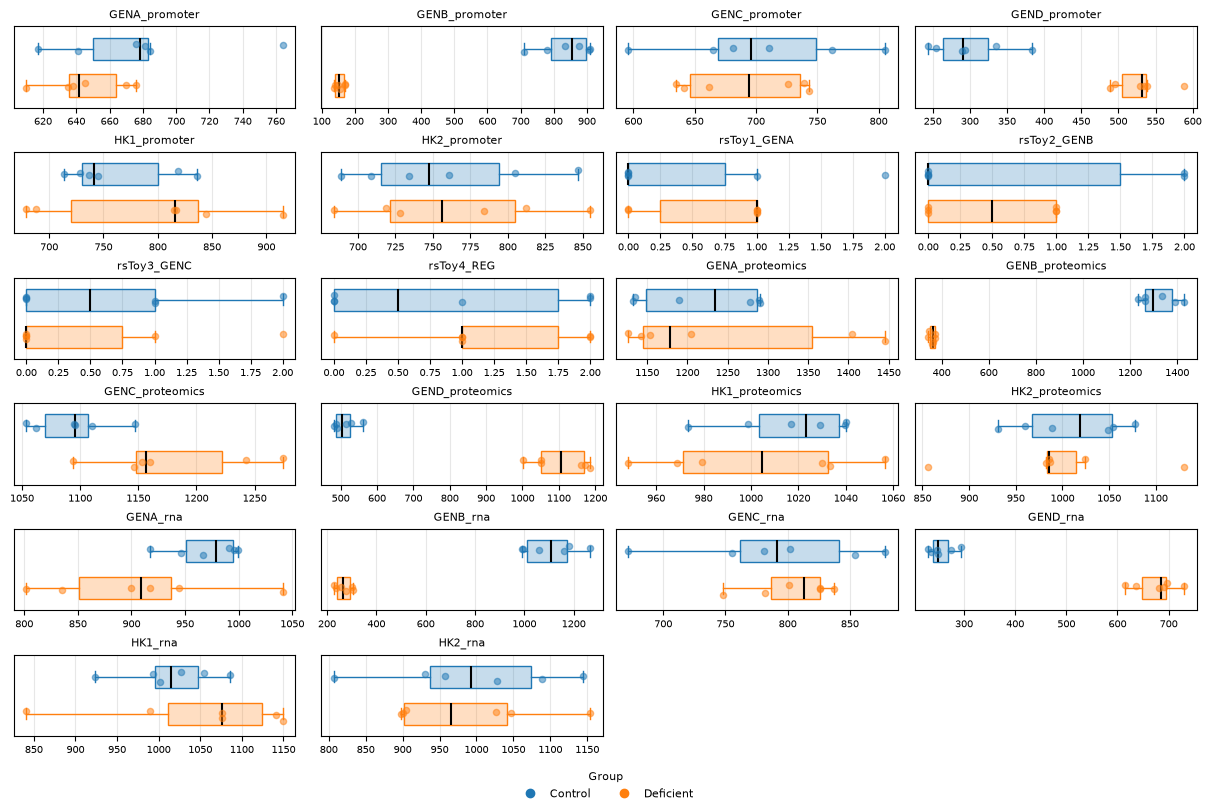

In [18]:
groups = sorted(df['group'].dropna().unique())
palette = dict(zip(groups, plt.cm.tab10(np.arange(len(groups)))))

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()
rng = np.random.default_rng(42)

for ax, col in zip(axes, features):
    sub = df[[col, 'group']].dropna(subset=[col])

    for pos, g in enumerate(groups, start=1):
        data = sub.loc[sub['group'] == g, col].values
        if len(data) == 0:
            continue

        ax.boxplot(
            data, positions=[pos], orientation='horizontal',
            widths=0.6, showfliers=False, patch_artist=True,
            boxprops=dict(facecolor=to_rgba(palette[g], 0.25), edgecolor=palette[g]),
            whiskerprops=dict(color=palette[g]),
            capprops=dict(color=palette[g]),
            medianprops=dict(color='black', linewidth=1.5)
        )

        y = rng.normal(pos, 0.07, size=len(data))
        ax.scatter(data, y, s=20, alpha=0.5, color=palette[g], zorder=3)

    ax.set_title(col, fontsize=8)
    ax.set_yticks([])
    ax.set_ylim(len(groups) + 0.6, 0.4)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

for ax in axes[len(features):]:
    ax.axis('off')

handles = [plt.Line2D([], [], marker='o', linestyle='', color=palette[g], markersize=6, label=str(g)) for g in groups]

fig.legend(
    handles=handles, title='Group', loc='outside lower center',
    ncol=len(groups), fontsize=8, title_fontsize=8, frameon=False
)

fig;

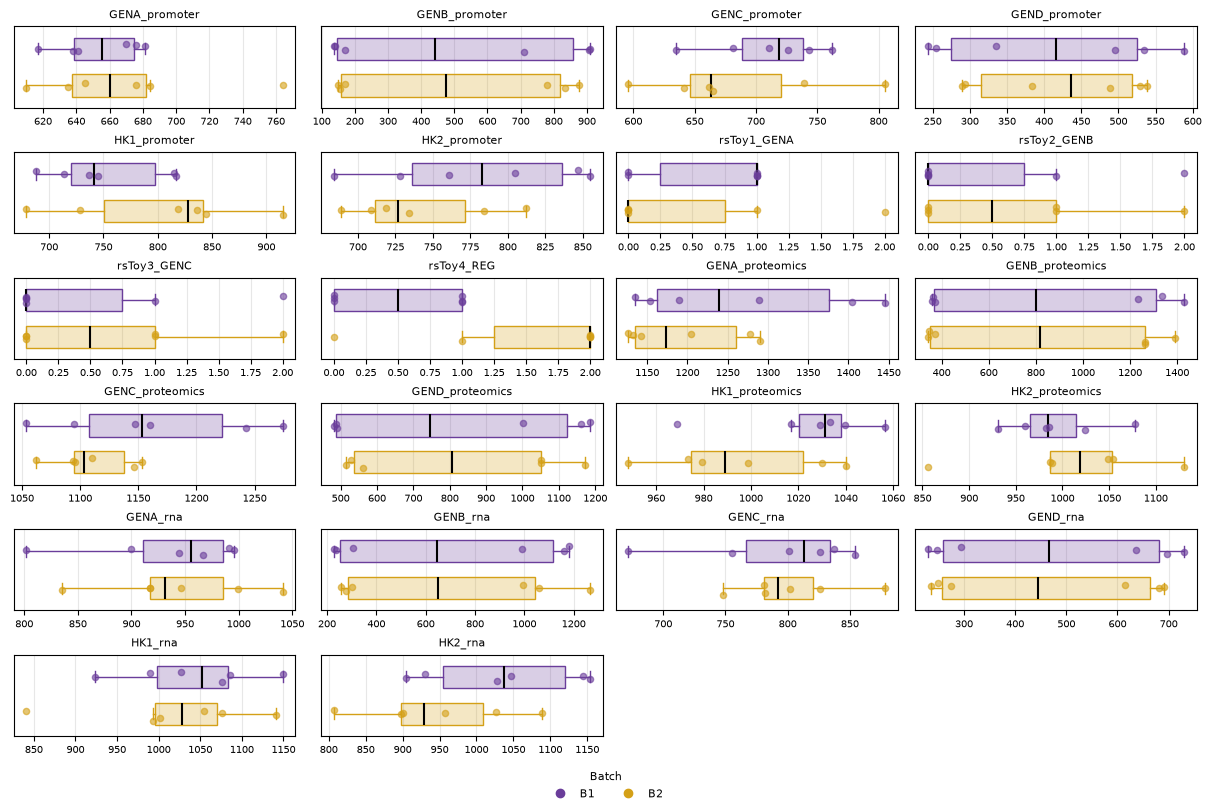

In [19]:
batches = sorted(df['batch'].dropna().unique())
palette = dict(zip(batches, ['#6a3d9a', '#d4a017']))

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()
rng = np.random.default_rng(42)

for ax, col in zip(axes, features):
    sub = df[[col, 'batch']].dropna(subset=[col])

    for pos, b in enumerate(batches, start=1):
        data = sub.loc[sub['batch'] == b, col].values
        if len(data) == 0:
            continue

        ax.boxplot(
            data, positions=[pos], orientation='horizontal',
            widths=0.6, showfliers=False, patch_artist=True,
            boxprops=dict(facecolor=to_rgba(palette[b], 0.25), edgecolor=palette[b]),
            whiskerprops=dict(color=palette[b]),
            capprops=dict(color=palette[b]),
            medianprops=dict(color='black', linewidth=1.5)
        )

        y = rng.normal(pos, 0.07, size=len(data))
        ax.scatter(data, y, s=20, alpha=0.6, color=palette[b], zorder=3)

    ax.set_title(col, fontsize=8)
    ax.set_yticks([])
    ax.set_ylim(len(batches) + 0.6, 0.4)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

for ax in axes[len(features):]:
    ax.axis('off')

handles = [plt.Line2D([], [], marker='o', linestyle='', color=palette[b], markersize=6, label=str(b)) for b in batches]

fig.legend(
    handles=handles, title='Batch', loc='outside lower center',
    ncol=len(batches), fontsize=8, title_fontsize=8, frameon=False
)

fig;

# 2. Pré-processamento

## 2.1. Valores ausentes

In [20]:
df.isnull().sum()

sample_id          0
GENA_promoter      0
GENB_promoter      0
GENC_promoter      0
GEND_promoter      0
HK1_promoter       0
HK2_promoter       0
rsToy1_GENA        0
rsToy2_GENB        0
rsToy3_GENC        0
rsToy4_REG         0
group              0
phenotype          0
batch              0
GENA_proteomics    0
GENB_proteomics    0
GENC_proteomics    0
GEND_proteomics    0
HK1_proteomics     0
HK2_proteomics     0
GENA_rna           0
GENB_rna           0
GENC_rna           0
GEND_rna           0
HK1_rna            0
HK2_rna            0
dtype: int64

## 2.2. Efeito do lote

In [21]:
df_cross = pd.crosstab(df["batch"], df['group'], margins=True, margins_name="Total")
df_cross

group,Control,Deficient,Total
batch,,,
B1,3,3,6
B2,3,3,6
Total,6,6,12


## 2.3. Normalização das contagens

In [22]:
def normalize(df_counts, method):
    # nenhuma normalização
    if method == "NENHUMA":
        return df_counts.copy()
    # contagens por milhão
    if method == "CPM":
        total = df_counts.sum(axis=1)
        return df_counts.div(total, axis=0) * 1e6
    # divisão pela média das contagens de housekeeping
    if method == "HK":
        hk_cols = [c for c in df_counts.columns if c.startswith("HK")]
        factor = df_counts[hk_cols].mean(axis=1)
        return df_counts.div(factor, axis=0)
    # mediana das razões
    if method == "MR":
        reference = np.exp(np.log(df_counts).mean(axis=0))
        ratios = df_counts.div(reference, axis=1)
        factor = ratios.median(axis=1)
        return df_counts.div(factor, axis=0)
    raise ValueError(f"Método de normalização desconhecido: {method}")

In [23]:
atac_cols = [c for c in df.columns if c.endswith("_promoter")]
rna_cols = [c for c in df.columns if c.endswith("_rna")]

In [24]:
metodo = "CPM"  #@param ["NENHUMA", "CPM", "HK", "MR"] {type:"string"}

df_norm = df.copy()
df_norm[atac_cols] = normalize(df[atac_cols], metodo)
df_norm[rna_cols] = normalize(df[rna_cols], metodo)
df_norm

,sample_id,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,...,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,GENA_rna,GENB_rna,GENC_rna,GEND_rna,HK1_rna,HK2_rna
0,S01,152157.829840,224414.303329,167940.813810,62885.326757,183723.797781,208877.928483,0,0,2,...,1053.74,481.60,1029.16,931.07,188850.967008,223549.488055,143155.100493,43610.163064,205915.813424,194918.467956
1,S02,176196.636481,183699.870634,183958.602846,63130.659767,184734.799483,208279.430789,1,0,0,...,1095.08,489.61,1039.74,960.05,190279.417552,228256.591893,168044.077135,48799.685163,181621.408894,182998.819362
2,S03,154756.156446,218734.910671,183969.097055,80878.802511,177933.365524,183727.667793,0,2,1,...,1146.85,487.02,1017.06,1077.44,193592.498535,193397.147880,131275.639773,57628.443055,200625.122094,223481.148662
3,S04,171000.000000,208250.000000,166250.000000,73250.000000,209000.000000,172250.000000,0,0,0,...,1095.92,561.81,973.28,989.07,169689.119171,234455.958549,148408.586232,50888.230940,195040.710585,201517.394523
4,S05,165808.192298,191071.866569,197449.104734,70885.454991,200883.002208,173902.379200,0,2,0,...,1061.68,529.04,998.58,1054.18,198406.040268,208892.617450,163800.335570,49496.644295,210151.006711,169253.355705
5,S06,187209.017398,214408.233276,146042.636609,94094.584661,178387.650086,179857.877971,2,0,1,...,1110.27,515.51,1040.04,1048.68,194509.345794,206191.588785,170950.155763,48676.012461,193341.121495,186331.775701
6,S07,173087.357569,37167.661422,201573.521432,134563.212154,221649.484536,231958.762887,1,0,0,...,1159.84,1186.16,1056.43,982.24,186721.991701,63070.539419,173651.452282,131950.207469,205186.721992,239419.087137
7,S08,189909.297052,48469.387755,205782.312925,166950.113379,195011.337868,193877.551020,1,1,0,...,1242.83,1001.16,968.70,985.71,201494.130203,48665.955176,170971.184632,156029.882604,229669.156884,193169.690502
8,S09,191609.977324,39399.092971,179988.662132,151643.990930,231009.070295,206349.206349,1,0,0,...,1274.07,1162.20,1033.40,1023.61,168629.100084,49621.530698,173675.357443,146341.463415,241589.571068,220142.977292
9,S10,170094.936709,45094.936709,194883.966245,141877.637131,241297.468354,206751.054852,0,1,1,...,1094.24,1051.27,1029.77,1130.74,229093.309859,56117.957746,181778.169014,149867.957746,185079.225352,198063.380282


## 2.4. Diferença entre os grupos

In [25]:
df[["group", "GENA_promoter", "GENB_promoter", "GENC_promoter", "GEND_promoter"]].groupby("group").mean()

,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter
group,,,,
Control,677.166667,835.5,703.333333,300.000000
Deficient,645.666667,153.5,691.000000,529.333333


In [26]:
variables = [c for c in df_norm.columns if c.endswith(("_promoter", "_rna", "_proteomics"))]
control = df_norm[df_norm["phenotype"] == 0]
deficient = df_norm[df_norm["phenotype"] == 1]

rows = []
for col in variables:
    a = np.log2(control[col])
    b = np.log2(deficient[col])
    log2fc = b.mean() - a.mean()
    deviation = np.sqrt((a.var() + b.var()) / 2)
    d = log2fc / deviation
    p = stats.ttest_ind(b, a).pvalue
    rows.append({"variable": col, "log2fc": log2fc, "d": d, "p": p})

df_dif = pd.DataFrame(rows)
df_dif

,variable,log2fc,d,p
0,GENA_promoter,0.108923,1.158712,7.254303e-02
1,GENB_promoter,-2.269254,-17.542583,3.492312e-11
2,GENC_promoter,0.153274,1.266217,5.305227e-02
3,GEND_promoter,1.009336,5.788120,1.553128e-06
4,HK1_promoter,0.224935,1.934285,7.361874e-03
5,HK2_promoter,0.186440,1.544598,2.327892e-02
6,GENA_proteomics,0.026447,0.203793,7.314312e-01
7,GENB_proteomics,-1.872182,-26.056909,6.863041e-13
8,GENC_proteomics,0.105970,1.616720,1.878680e-02
9,GEND_proteomics,1.111037,11.641969,1.980891e-09


In [27]:
correction = "BENJAMINI_HOCHBERG"  #@param ["NENHUMA", "BONFERRONI", "BENJAMINI_HOCHBERG"] {type:"string"}

# sem correção
if correction == "NENHUMA":
    df_dif["p_corrected"] = df_dif["p"]
# correção de Bonferroni
elif correction == "BONFERRONI":
    df_dif["p_corrected"] = (df_dif["p"] * len(df_dif)).clip(upper=1)
# correção de Benjamini-Hochberg
elif correction == "BENJAMINI_HOCHBERG":
    df_dif["p_corrected"] = stats.false_discovery_control(df_dif["p"], method="bh")
else:
    raise ValueError(f"Método de correção desconhecido: {correction}")

df_dif["significant"] = df_dif["p_corrected"] < 0.05
df_dif.sort_values("p_corrected")

,variable,log2fc,d,p,p_corrected,significant
7,GENB_proteomics,-1.872182,-26.056909,6.863041e-13,1.235347e-11,True
1,GENB_promoter,-2.269254,-17.542583,3.492312e-11,3.143081e-10,True
15,GEND_rna,1.533572,13.672714,4.090381e-10,2.454229e-09,True
13,GENB_rna,-1.927202,-13.200167,5.780646e-10,2.601291e-09,True
9,GEND_proteomics,1.111037,11.641969,1.980891e-09,7.131209e-09,True
3,GEND_promoter,1.009336,5.788120,1.553128e-06,4.659385e-06,True
4,HK1_promoter,0.224935,1.934285,7.361874e-03,1.893053e-02,True
8,GENC_proteomics,0.105970,1.616720,1.878680e-02,4.227029e-02,True
5,HK2_promoter,0.186440,1.544598,2.327892e-02,4.655784e-02,True
14,GENC_rna,0.158108,1.394436,3.635666e-02,6.204477e-02,False


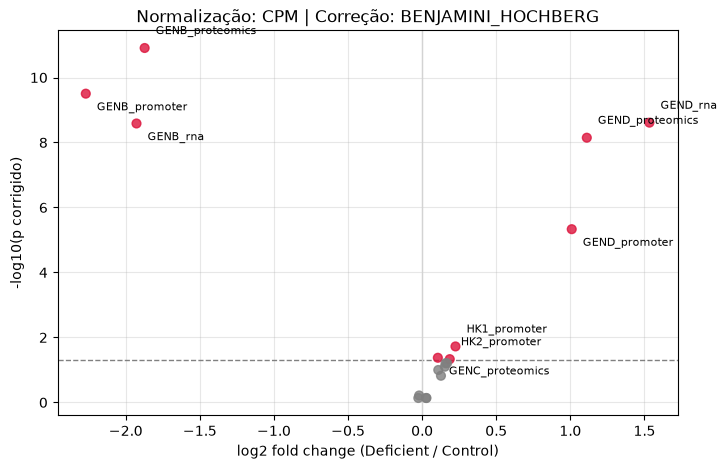

In [28]:
limit = 0.05
df_dif["minus_log10_p"] = -np.log10(df_dif["p_corrected"])
colors = df_dif["significant"].map({True: "crimson", False: "gray"})

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_dif["log2fc"], df_dif["minus_log10_p"], c=colors, s=40, alpha=0.8, zorder=3)
ax.axhline(-np.log10(limit), color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="lightgray", linewidth=1)

significant = df_dif[df_dif["significant"]].sort_values("minus_log10_p")
for i, (_, linha) in enumerate(significant.iterrows()):
    shift = 10 if i % 2 == 0 else -12
    ax.annotate(
        linha["variable"],
        (linha["log2fc"], linha["minus_log10_p"]),
        xytext=(8, shift), textcoords="offset points", fontsize=8,
    )
    
ax.set_title(f"Normalização: {metodo} | Correção: {correction}")
ax.set_xlabel("log2 fold change (Deficient / Control)")
ax.set_ylabel("-log10(p corrigido)")
ax.grid(alpha=0.3)

# 3. Transformação

In [29]:
all_layers = ["ATAC", "RNA", "PROTEOMICA", "GENOTIPOS"]
genes = ["GENA", "GENB", "GENC", "GEND", "HK1", "HK2"]
group_colors = {"Control": "tab:blue", "Deficient": "tab:orange"}

In [30]:
def layer_columns(data, layer):
    if layer == "ATAC":
        return [c for c in data.columns if c.endswith("_promoter")]
    if layer == "RNA":
        return [c for c in data.columns if c.endswith("_rna")]
    if layer == "PROTEOMICA":
        return [c for c in data.columns if c.endswith("_proteomics")]
    if layer == "GENOTIPOS":
        return [c for c in data.columns if c.startswith("rs")]
    raise ValueError(f"Camada desconhecida: {layer}")

In [31]:
def build_xy(data, layers, excluded_genes=()):
    columns = []
    for layer in layers:
        columns += layer_columns(data, layer)
    columns = [c for c in columns if c.startswith("rs") or c.split("_")[0] not in excluded_genes]
    if len(columns) == 0:
        raise ValueError("Nenhuma variável selecionada")

    X = data[columns].copy()
    continuous = [c for c in columns if not c.startswith("rs")]
    X[continuous] = np.log2(X[continuous] + 1)
    y = data["phenotype"]
    return X, y

In [32]:
X, y = build_xy(df, all_layers)

print(f"Amostras: {X.shape[0]}, variáveis: {X.shape[1]}")
X

Amostras: 12, variáveis: 22


,GENA_promoter,GENB_promoter,GENC_promoter,GEND_promoter,HK1_promoter,HK2_promoter,GENA_rna,GENB_rna,GENC_rna,GEND_rna,...,GENA_proteomics,GENB_proteomics,GENC_proteomics,GEND_proteomics,HK1_proteomics,HK2_proteomics,rsToy1_GENA,rsToy2_GENB,rsToy3_GENC,rsToy4_REG
0,9.271463,9.831307,9.413628,8.000000,9.543032,9.727920,9.961450,10.204571,9.562242,7.851749,...,10.148896,10.483685,10.042672,8.914684,10.008653,9.864294,0,0,2,1
1,9.413628,9.473706,9.475733,7.936638,9.481799,9.654636,9.918863,10.181152,9.739781,7.960002,...,10.217206,10.268717,10.098137,8.938433,10.023394,9.908468,1,0,0,0
2,9.326429,9.824959,9.575539,8.392317,9.527477,9.573647,9.954196,9.952741,9.394463,8.209453,...,10.333536,10.382786,10.164718,8.930796,9.991607,10.074730,0,2,1,0
3,9.419960,9.703904,9.379378,8.199672,9.709084,9.430453,9.842350,10.308339,9.649256,8.108524,...,10.334530,10.304294,10.099243,9.136504,9.928193,9.951387,0,0,0,0
4,9.403012,9.607330,9.654636,8.179909,9.679480,9.471675,9.887221,9.961450,9.611025,7.888743,...,10.321105,10.302639,10.053492,9.049957,9.965178,10.043273,0,2,0,2
5,9.579316,9.774787,9.221587,8.588715,9.509775,9.521600,9.965784,10.049849,9.779719,7.971544,...,10.146301,10.444684,10.117994,9.012652,10.023810,10.035734,2,0,1,2
6,9.319672,7.108524,9.539159,8.957102,9.675957,9.741467,9.815383,8.252665,9.710806,9.315150,...,10.497862,8.514201,10.180953,10.213299,10.046346,9.941400,1,0,0,1
7,9.390169,7.426265,9.505812,9.204571,9.428360,9.419960,9.884171,7.839204,9.647458,9.515700,...,10.457094,8.497173,10.280574,9.968897,9.921395,9.946482,1,1,0,0
8,9.403012,7.129283,9.312883,9.066089,9.672425,9.509775,9.649256,7.888743,9.691744,9.445015,...,10.172765,8.546200,10.316361,10.183883,10.014578,10.000859,1,0,0,1
9,9.335390,7.426265,9.531381,9.074141,9.839204,9.616549,10.025140,8.000000,9.691744,9.413628,...,10.234817,8.549323,10.097031,10.039289,10.009507,10.144327,0,1,1,2


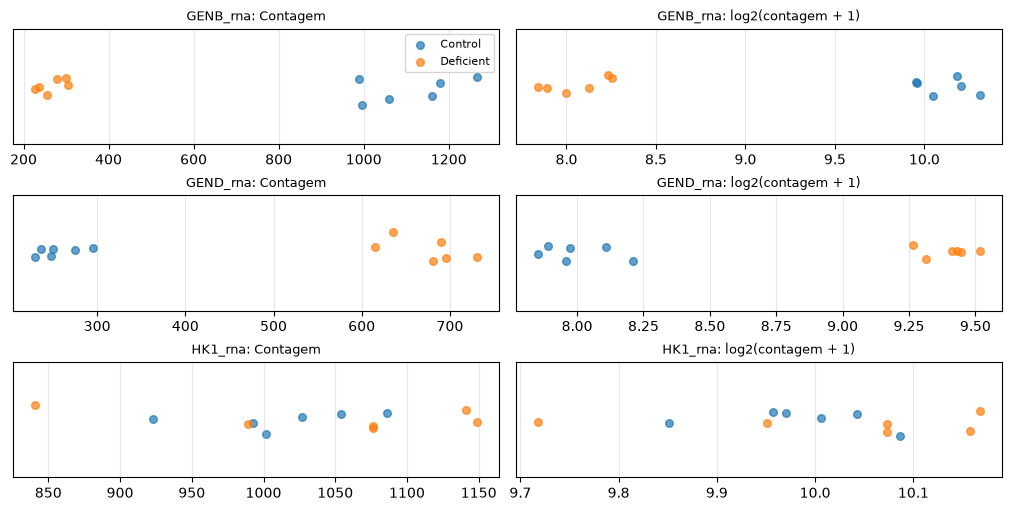

In [33]:
example_columns = ["GENB_rna", "GEND_rna", "HK1_rna"]
rng = np.random.default_rng(42)

fig, axes = plt.subplots(nrows=len(example_columns), ncols=2, figsize=(10, 5), constrained_layout=True)

for row, col in enumerate(example_columns):
    for pos, (label, values) in enumerate([("Contagem", df[col]), ("log2(contagem + 1)", X[col])]):
        ax = axes[row, pos]
        for g, color in group_colors.items():
            mask = df["group"] == g
            ax.scatter(values[mask], rng.normal(0, 0.05, mask.sum()), s=30, alpha=0.7, color=color, label=g)
        ax.set_yticks([])
        ax.set_ylim(-0.3, 0.3)
        ax.set_title(f"{col}: {label}", fontsize=9)
        ax.grid(axis="x", alpha=0.3)

axes[0, 0].legend(fontsize=8)
fig;

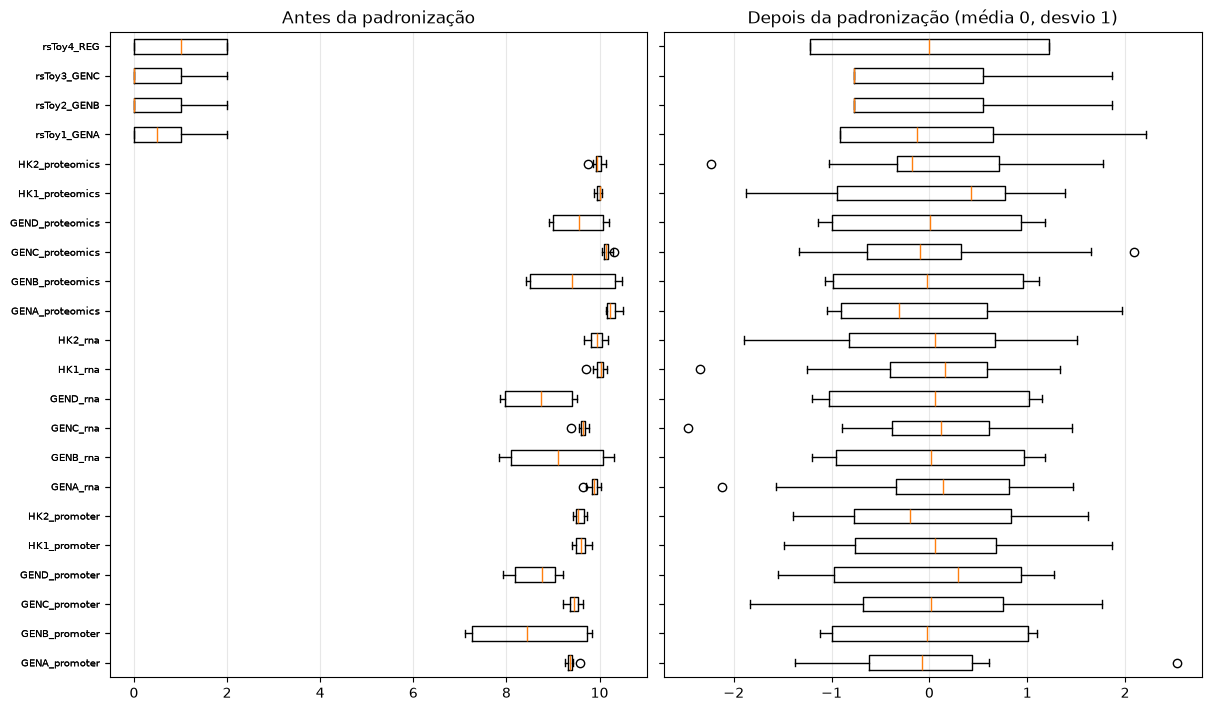

In [34]:
X_scaled_view = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

fig, axes = plt.subplots(ncols=2, figsize=(12, 7), sharey=True, constrained_layout=True)

axes[0].boxplot(X.values, orientation="horizontal", tick_labels=X.columns)
axes[0].set_title("Antes da padronização")
axes[1].boxplot(X_scaled_view.values, orientation="horizontal", tick_labels=X.columns)
axes[1].set_title("Depois da padronização (média 0, desvio 1)")

for ax in axes:
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="x", alpha=0.3)

fig;

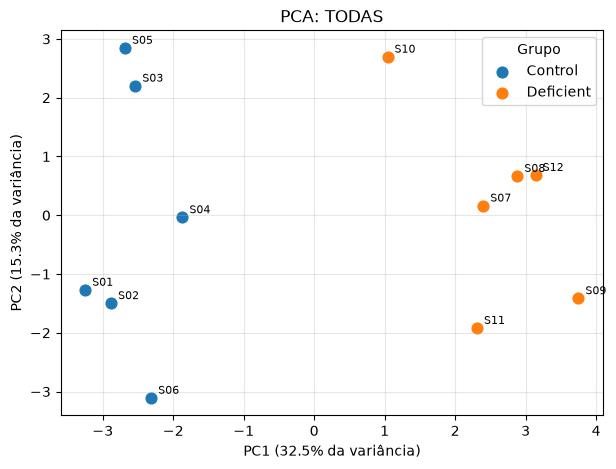

In [35]:
camada_pca = "TODAS"  #@param ["TODAS", "ATAC", "RNA", "PROTEOMICA", "GENOTIPOS"] {type:"string"}

layers_pca = all_layers if camada_pca == "TODAS" else [camada_pca]
X_pca, _ = build_xy(df, layers_pca)

pca = PCA(n_components=2)
components = pca.fit_transform(StandardScaler().fit_transform(X_pca))
explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(7, 5))
for g, color in group_colors.items():
    mask = (df["group"] == g).values
    ax.scatter(components[mask, 0], components[mask, 1], s=60, color=color, label=g)
for i, sample in enumerate(df["sample_id"]):
    ax.annotate(sample, (components[i, 0], components[i, 1]), xytext=(5, 3), textcoords="offset points", fontsize=8)

ax.set_title(f"PCA: {camada_pca}")
ax.set_xlabel(f"PC1 ({explained[0]:.1f}% da variância)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% da variância)")
ax.legend(title="Grupo")
ax.grid(alpha=0.3)

# 4. Mineração de dados

In [ ]:
model_names = ["REGRESSAO_LOGISTICA", "SVM", "RANDOM_FOREST"]

def make_model(model_name, seed=42):
    if model_name == "REGRESSAO_LOGISTICA":
        return LogisticRegression(max_iter=1000)
    if model_name == "SVM":
        return SVC(kernel="rbf")
    if model_name == "RANDOM_FOREST":
        return RandomForestClassifier(n_estimators=100, random_state=seed)
    raise ValueError(f"Modelo desconhecido: {model_name}")

In [ ]:
def evaluate(X, y, model_name, seed=42):
    loo = LeaveOneOut()
    y_pred = np.zeros_like(y)

    for train_index, test_index in loo.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train = y.iloc[train_index]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = make_model(model_name, seed)
        model.fit(X_train_scaled, y_train)
        y_pred[test_index] = model.predict(X_test_scaled)

    return accuracy_score(y, y_pred), confusion_matrix(y, y_pred)

In [ ]:
baseline = y.value_counts(normalize=True).max()
print(f"Acerto de quem chuta sempre o mesmo grupo: {baseline:.0%}")

Acerto de quem chuta sempre o mesmo grupo: 50%


Acurácia: 100%


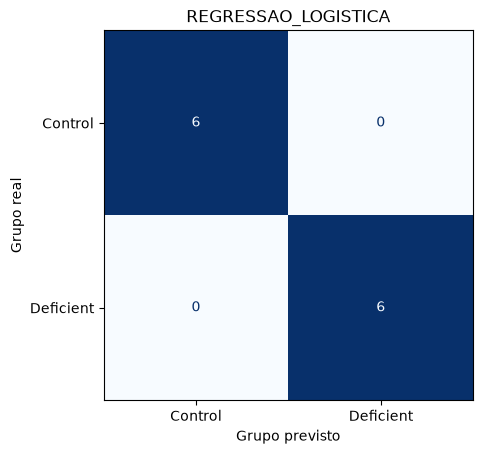

In [ ]:
modelo = "REGRESSAO_LOGISTICA"  #@param ["REGRESSAO_LOGISTICA", "SVM", "RANDOM_FOREST"] {type:"string"}

accuracy, matrix = evaluate(X, y, modelo)
print(f"Acurácia: {accuracy:.0%}")

cm_display = ConfusionMatrixDisplay(matrix, display_labels=["Control", "Deficient"])
cm_display.plot(cmap="Blues", colorbar=False)
cm_display.ax_.set_title(modelo)
cm_display.ax_.set_xlabel("Grupo previsto")
cm_display.ax_.set_ylabel("Grupo real");

In [ ]:
results = []
for model_name in model_names:
    accuracy, _ = evaluate(X, y, model_name)
    results.append({"model": model_name, "accuracy": accuracy})

pd.DataFrame(results)

,model,accuracy
0,REGRESSAO_LOGISTICA,1.0
1,SVM,1.0
2,RANDOM_FOREST,1.0


# 5. Interpretação e avaliação

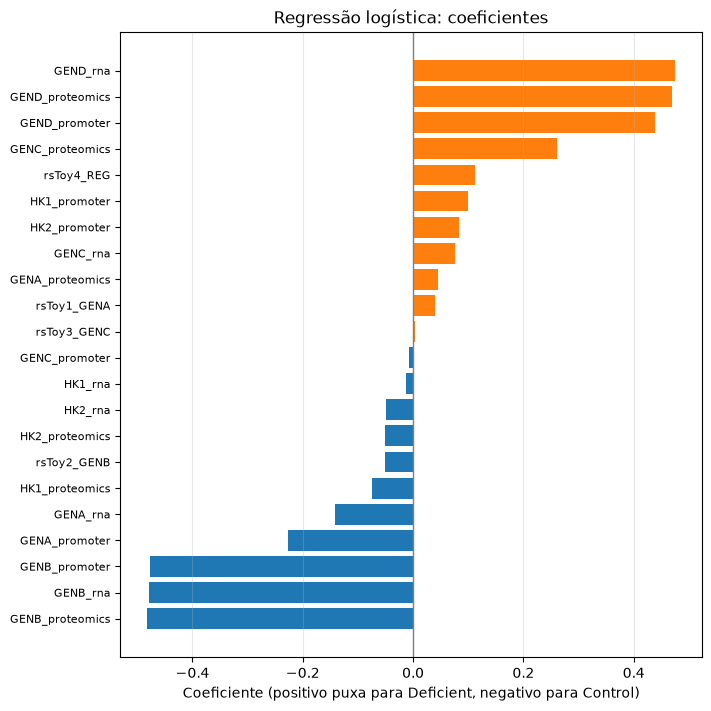

In [ ]:
X_scaled_full = StandardScaler().fit_transform(X)
logreg = LogisticRegression(max_iter=1000).fit(X_scaled_full, y)
coefficients = pd.Series(logreg.coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.barh(coefficients.index, coefficients.values, color=np.where(coefficients > 0, "tab:orange", "tab:blue"))
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Regressão logística: coeficientes")
ax.set_xlabel("Coeficiente (positivo puxa para Deficient, negativo para Control)")
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="x", alpha=0.3)

In [ ]:
def rf_importances(X, y, seeds):
    table = {}
    for seed in seeds:
        model = make_model("RANDOM_FOREST", seed)
        model.fit(X, y)
        table[seed] = model.feature_importances_
    return pd.DataFrame(table, index=X.columns)

In [ ]:
importances = rf_importances(X, y, seeds=range(10))

importances.idxmax().value_counts()

GEND_promoter      5
GENB_promoter      3
GEND_rna           1
GENB_proteomics    1
Name: count, dtype: int64

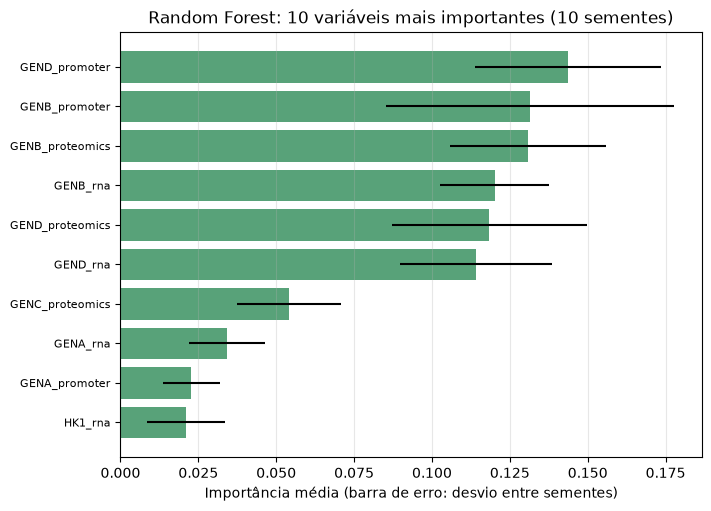

In [ ]:
top_mean = importances.mean(axis=1).sort_values().tail(10)
top_std = importances.std(axis=1)[top_mean.index]

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax.barh(top_mean.index, top_mean.values, xerr=top_std.values, color="seagreen", alpha=0.8)
ax.set_title("Random Forest: 10 variáveis mais importantes (10 sementes)")
ax.set_xlabel("Importância média (barra de erro: desvio entre sementes)")
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="x", alpha=0.3)

In [ ]:
sklearn_version = tuple(int(v) for v in sklearn.__version__.split(".")[:2])

def make_lasso(C):
    if sklearn_version >= (1, 8):
        return LogisticRegression(l1_ratio=1, C=C, solver="liblinear", tol=1e-6, max_iter=10000)
    return LogisticRegression(penalty="l1", C=C, solver="liblinear", tol=1e-6, max_iter=10000)

In [ ]:
def lasso_path(X, y, Cs):
    X_scaled = StandardScaler().fit_transform(X)
    path = {}
    for C in Cs:
        path[C] = make_lasso(C).fit(X_scaled, y).coef_[0]
    return pd.DataFrame(path, index=X.columns)

In [ ]:
Cs = np.logspace(-2, 1, 31)
path = lasso_path(X, y, Cs)

entry_C = {}
for variable in path.index:
    nonzero = path.columns[path.loc[variable] != 0]
    entry_C[variable] = nonzero.min() if len(nonzero) > 0 else np.nan

entry_C = pd.Series(entry_C, name="C_de_entrada").sort_values()
entry_C

GENB_proteomics     0.199526
GENB_rna            0.398107
GENB_promoter       1.995262
GEND_proteomics     1.995262
GEND_rna           10.000000
GENA_promoter            NaN
GENC_promoter            NaN
GEND_promoter            NaN
HK1_promoter             NaN
HK2_promoter             NaN
GENA_rna                 NaN
GENC_rna                 NaN
HK1_rna                  NaN
HK2_rna                  NaN
GENA_proteomics          NaN
GENC_proteomics          NaN
HK1_proteomics           NaN
HK2_proteomics           NaN
rsToy1_GENA              NaN
rsToy2_GENB              NaN
rsToy3_GENC              NaN
rsToy4_REG               NaN
Name: C_de_entrada, dtype: float64

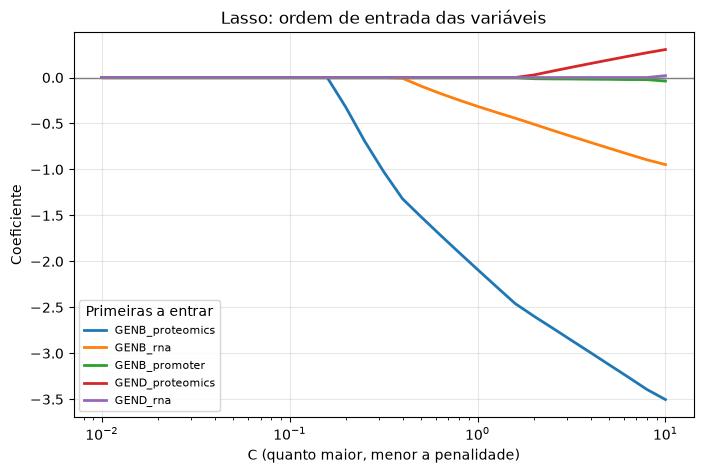

In [ ]:
first_entries = entry_C.dropna().index[:6]

fig, ax = plt.subplots(figsize=(8, 5))
for variable in path.index:
    if variable not in first_entries:
        ax.plot(Cs, path.loc[variable], color="lightgray", linewidth=1)
for variable in first_entries:
    ax.plot(Cs, path.loc[variable], linewidth=2, label=variable)

ax.set_xscale("log")
ax.axhline(0, color="gray", linewidth=1)
ax.set_title("Lasso: ordem de entrada das variáveis")
ax.set_xlabel("C (quanto maior, menor a penalidade)")
ax.set_ylabel("Coeficiente")
ax.legend(title="Primeiras a entrar", fontsize=8)
ax.grid(alpha=0.3)

# 6. Retorno à seleção

# 7. Simulador

# 8. Conclusão

# Referências